In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv('customers_sales.csv')
customers.join_date = pd.to_datetime(customers.join_date, errors= 'coerce')
customers.head()

,customer_id,age,gender,loyalty_member,join_date,product_name,avg_spending,total_orders,quantity,total_sales,customer_retention
0,C003898,42,Female,1,2025-03-16,Truffle Chocolate 50%,27.944375,32,99,894.22,17
1,C033309,46,Male,1,2021-12-29,White Chocolate 60%,30.337436,39,125,1183.16,17
2,C044674,56,Female,1,2023-01-18,Milk Chocolate 70%,27.809643,28,88,778.67,17
3,C044952,47,Male,1,2022-05-18,Dark Chocolate 50%,19.642250,40,102,785.69,17
4,C038641,49,Female,1,2023-11-18,Milk Chocolate 70%,22.050811,37,102,815.88,18


In [6]:
#Find how many customers have joined through years 
customers['year_join'] = customers.join_date.dt.year 
joind_in = customers.groupby('year_join')['customer_id'].count()
joind_in


year_join
2021     8238
2022    10002
2023     9886
2024     9993
2025    10088
2026     1793
Name: customer_id, dtype: int64

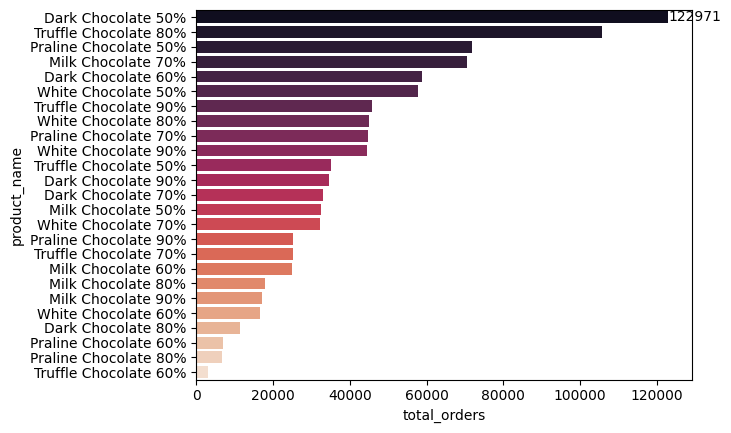

In [47]:
#Find the total customers for each product
count_products = customers.groupby('product_name')['total_orders'].sum().sort_values(ascending= False).reset_index()

chart= sns.barplot(data= count_products, x= 'total_orders', y= 'product_name', palette='rocket', hue= 'product_name')

chart.bar_label(chart.containers[0])
plt.show()
# count_products.plot.pie(x= count_products['total_orders'], labels= count_products['product_name'], autopct= '%1.0f%%', subplots=True)

array([<Axes: >], dtype=object)

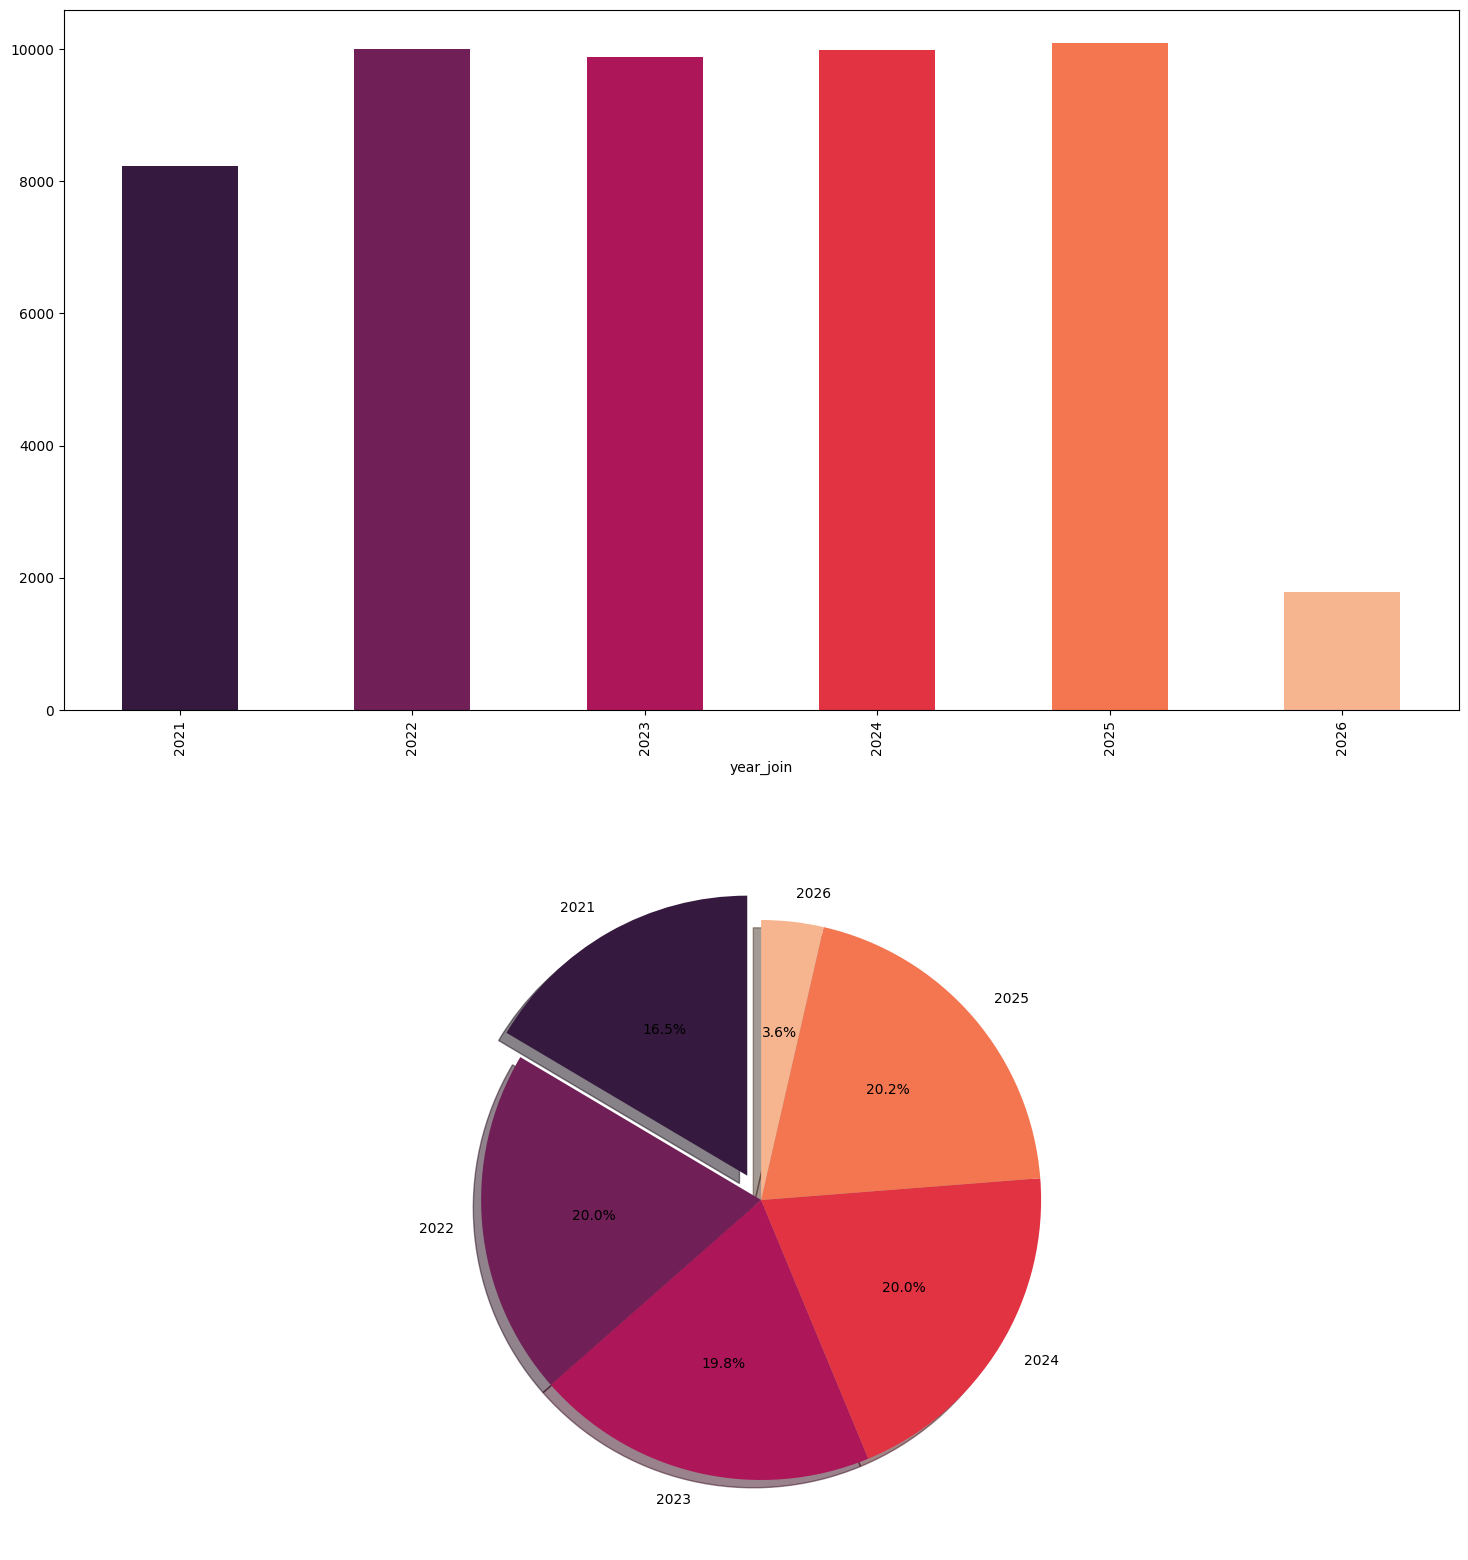

In [ ]:
aesthetic_colors = ['#C96F53', '#E5BA73', '#94B49F', '#5F8D7B', '#628495', '#DAB8B8', '#3F4E4F']
fig, axes = plt.subplots(ncols=1, nrows=2, figsize= (18,20))
out= (0.1, 0, 0, 0, 0, 0)
sns_colors= sns.color_palette('rocket', 6)
joind_in.plot(kind= 'bar', ax= axes[0],  color= sns_colors)
joind_in.plot.pie(x= joind_in.values,labels=joind_in.index, autopct= '%1.1f%%', startangle= 90, ax= axes[1],subplots= True, ylabel='', colors= sns_colors,shadow= True, explode = out)

C:\Users\Fatima\AppData\Local\Temp\ipykernel_33608\1222599514.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data= customers,x= 'customer_retention', y= 'total_orders', palette= 'GnBu', alpha= 0.7)


<Axes: xlabel='customer_retention', ylabel='total_orders'>

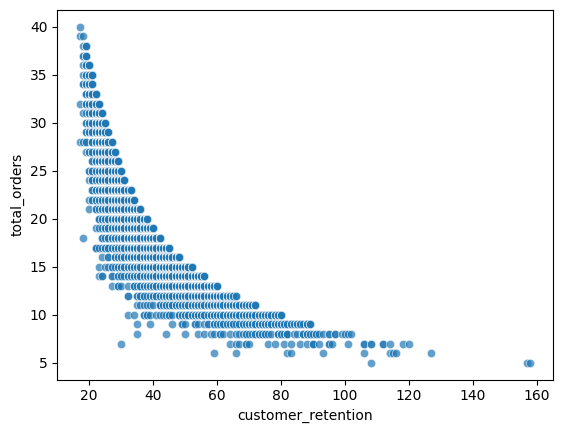

In [14]:


sns.scatterplot(data= customers,x= 'customer_retention', y= 'total_orders', palette= 'GnBu', alpha= 0.7)

<Axes: xlabel='loyalty_member', ylabel='customer_retention'>

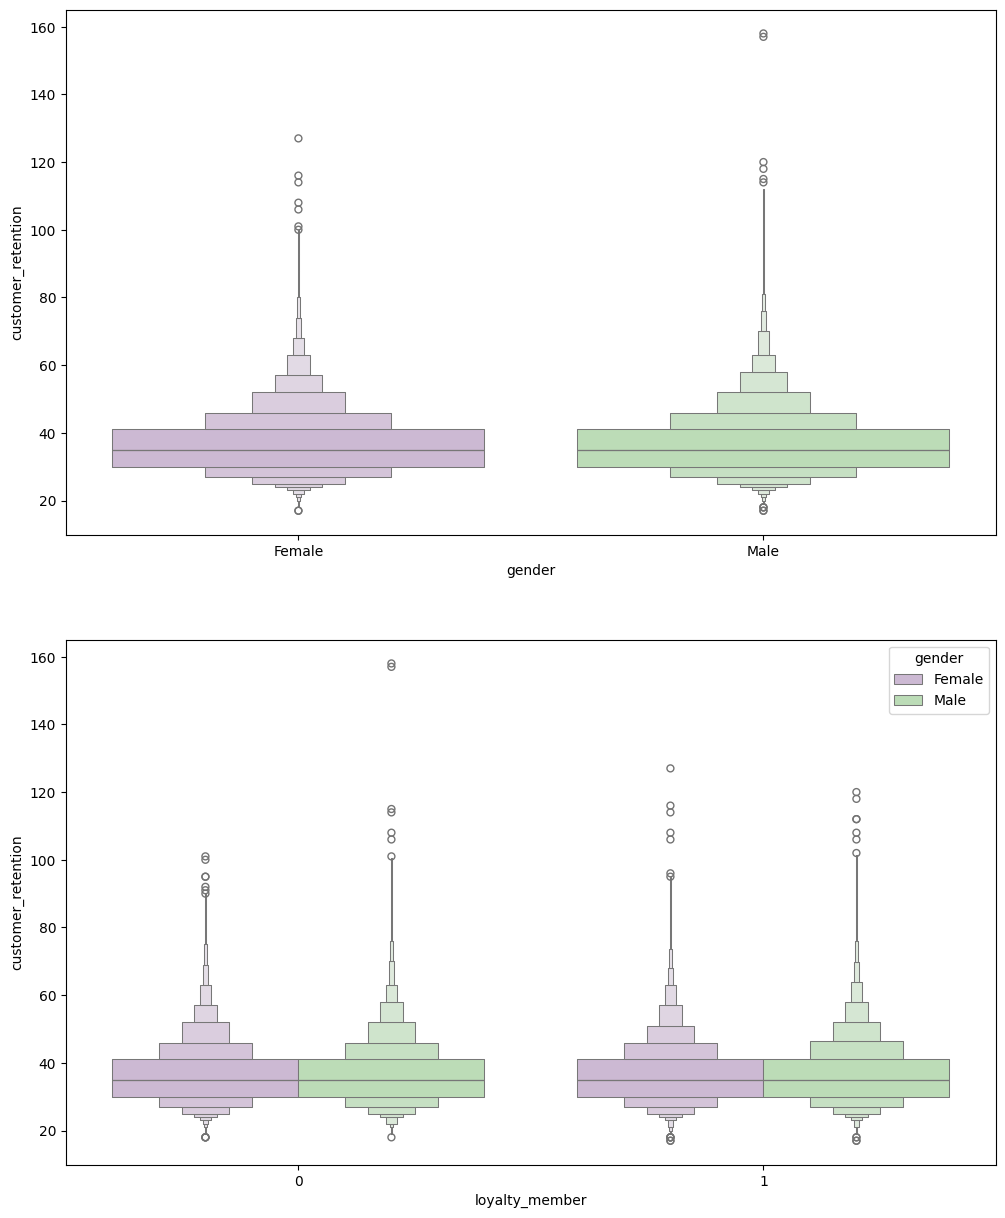

In [29]:
# apply boxplot to show 
fig, axes = plt.subplots(ncols=1, nrows=2,figsize=(12,15))
sns.boxenplot(data= customers, x= 'gender', y= 'customer_retention', palette='PRGn', hue= 'gender', ax= axes[0] )
sns.boxenplot(data= customers, x= 'loyalty_member', y= 'customer_retention', palette='PRGn', hue= 'gender', ax= axes[1] )

<Axes: xlabel='a_product', ylabel='customer_retention'>

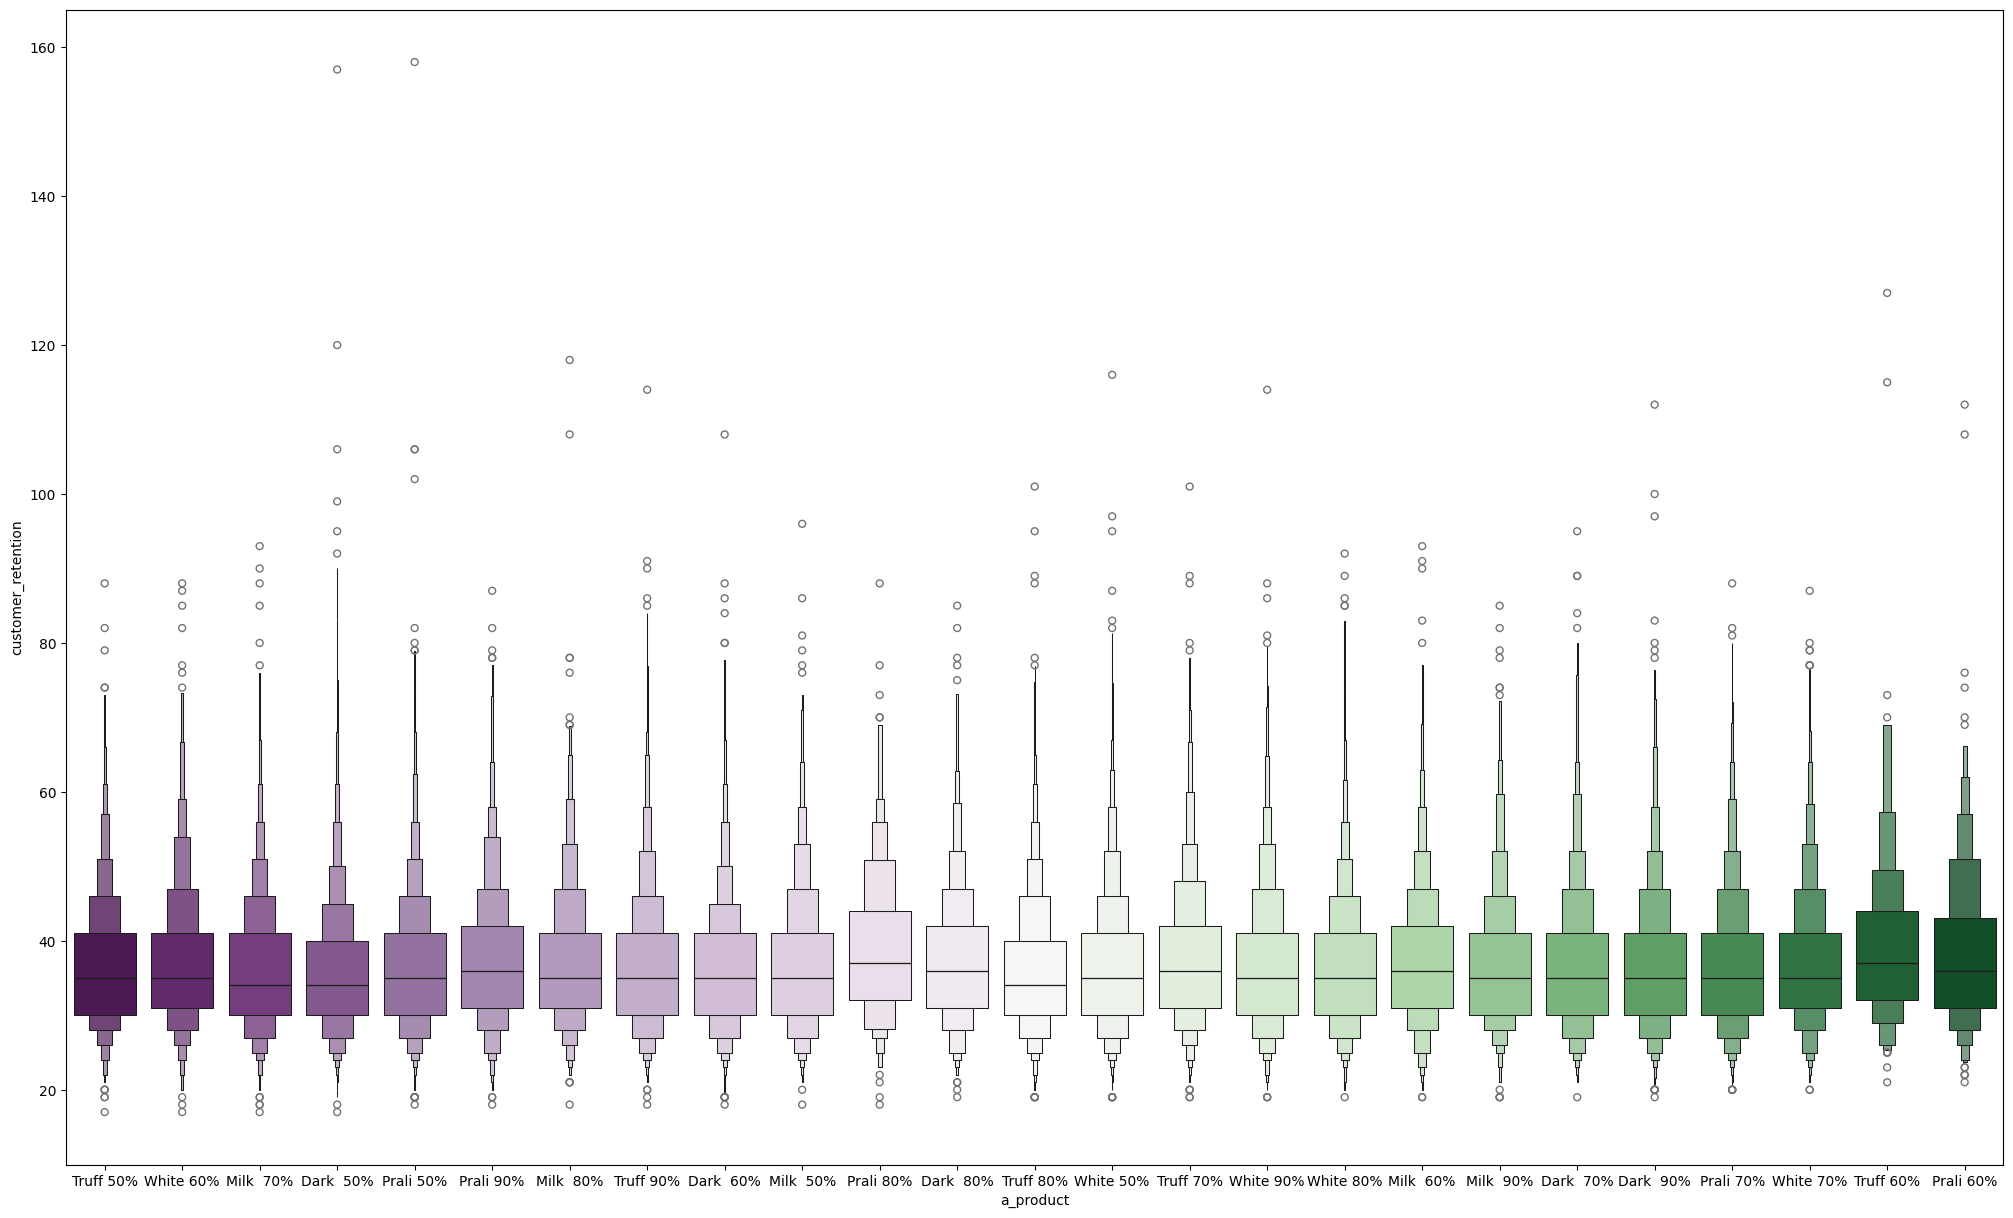

In [30]:
#Striping product names
plt.figure(figsize=(25,15))
customers['a_product'] = customers['product_name'].str.strip().str[:5] + ' '+ customers['product_name'].str.strip().str.split().str[-1]
sns.boxenplot(data= customers, x= 'a_product', y='customer_retention', hue= 'a_product', palette= 'PRGn' )